In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [25]:
df = pd.read_csv("netflix.csv")
df1 = df.copy()
df1.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df1.tail()

In [ ]:
df1.shape

In [38]:
df1.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added'],
      dtype='str')

In [3]:
df1['type'].unique()

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [5]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
df1.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [11]:
#data cleaning
df1.isnull().sum()

show_id            0
type               0
title              0
director        2624
cast             825
country          830
date_added         0
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [15]:
#check null value columns 
df1.isnull().sum()[df1.isnull().sum() > 0]


director    2624
cast         825
country      830
rating         4
duration       3
dtype: int64

In [16]:
df1.isnull().sum().sum()

np.int64(4286)

In [19]:
df1.dropna(subset=['date_added' ,'rating' ,'duration'],inplace=True)

In [34]:
df1['director'] = df1['director'].fillna("Unknown")
df1['cast'] = df1['cast'].fillna("Unknown")
df1['country'] = df1['country'].fillna("India")

In [35]:
df1.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [3]:
df1['date_added'] = df1['date_added'].astype(str).str.strip()
df1.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
#convert to_datetime
df1['date_added'] = pd.to_datetime(df1['date_added'], format="%B %d, %Y")    #B/b → month ka text (name) ,m → month ka number,M -- Minutes
df1['date_added']                                                           

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[us]

In [3]:
df1['duration']
(df1['duration'])

0          90 min
1       2 Seasons
2        1 Season
3        1 Season
4       2 Seasons
          ...    
8802      158 min
8803    2 Seasons
8804       88 min
8805       88 min
8806      111 min
Name: duration, Length: 8807, dtype: str

In [4]:
movies = df1[df1['type']=="Movie"]
tv = df1[df1['type']=='tv Show']

In [5]:
movies.shape

(6131, 12)

In [ ]:
movies.head()

In [42]:
df['type'].value_counts(normalize=True) * 100

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

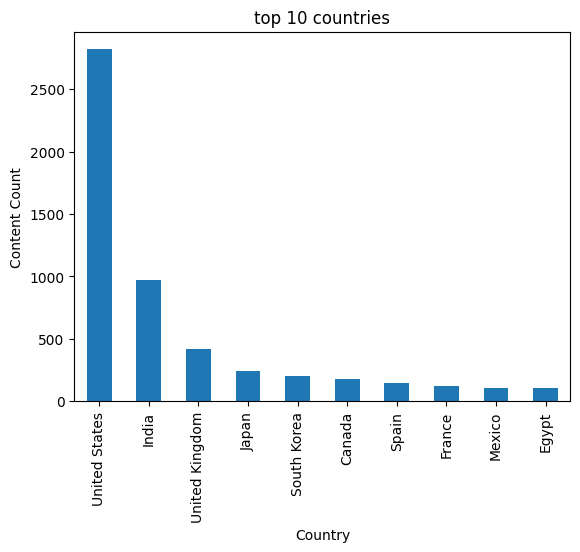

In [23]:
# top countries
df1['country'].value_counts().head(10).plot(kind='bar')
plt.title("top 10 countries")
plt.xlabel("Country")
plt.ylabel("Content Count")

plt.show()

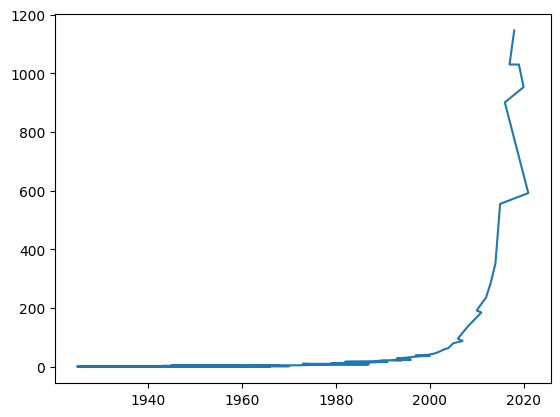

In [40]:
# release year :
plt.plot(df1['release_year'].value_counts())
plt.show()

In [18]:
df1['year_added'] = df1['date_added'].dt.year
df1['year_added']

0       2021.0
1       2021.0
2       2021.0
3       2021.0
4       2021.0
         ...  
8802    2019.0
8803    2019.0
8804    2019.0
8805    2020.0
8806    2019.0
Name: year_added, Length: 8807, dtype: float64

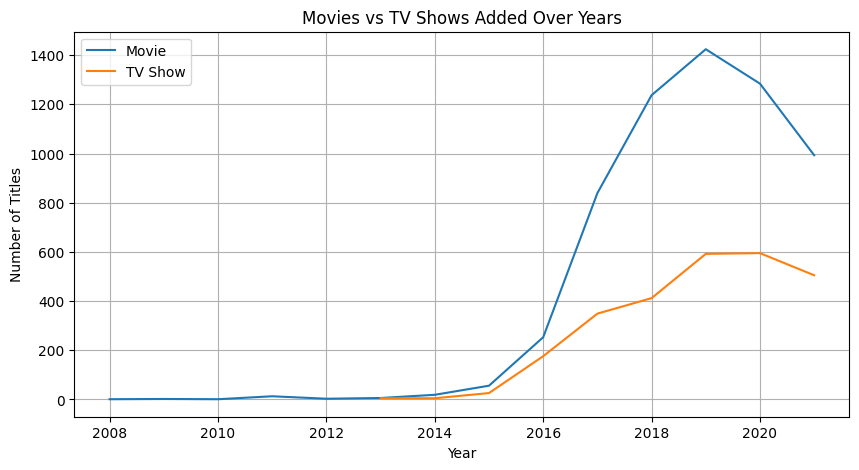

In [21]:
# year wise  ,movie and  tv trend
trend = df1.groupby(['year_added', 'type']).size().unstack()

plt.figure(figsize=(10,5))

plt.plot(trend.index, trend['Movie'], label='Movie')
plt.plot(trend.index, trend['TV Show'], label='TV Show')

plt.title("Movies vs TV Shows Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(True)
plt.legend()

plt.show()

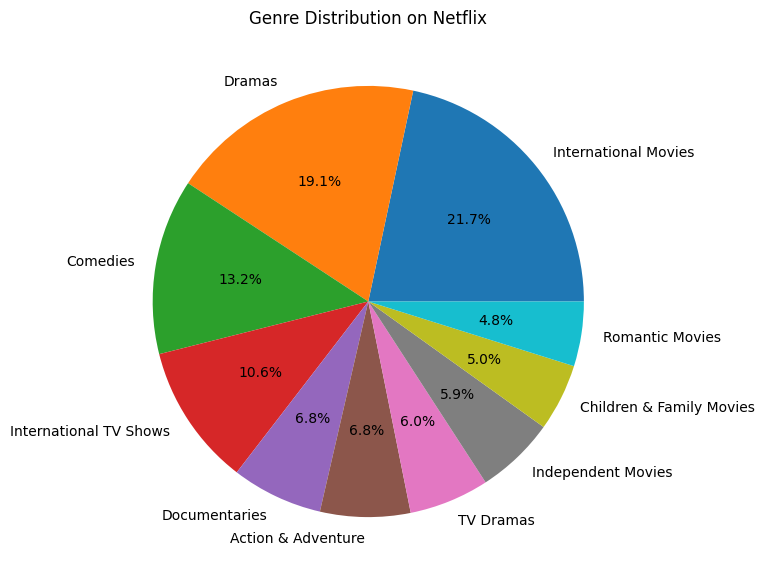

In [ ]:
#genre Distribution on netflix
plt.figure(figsize=(7,7))

plt.pie(
    top_genres.values,
    labels=top_genres.index,
    autopct='%1.1f%%'
)

plt.title("Genre Distribution on Netflix")

plt.show()

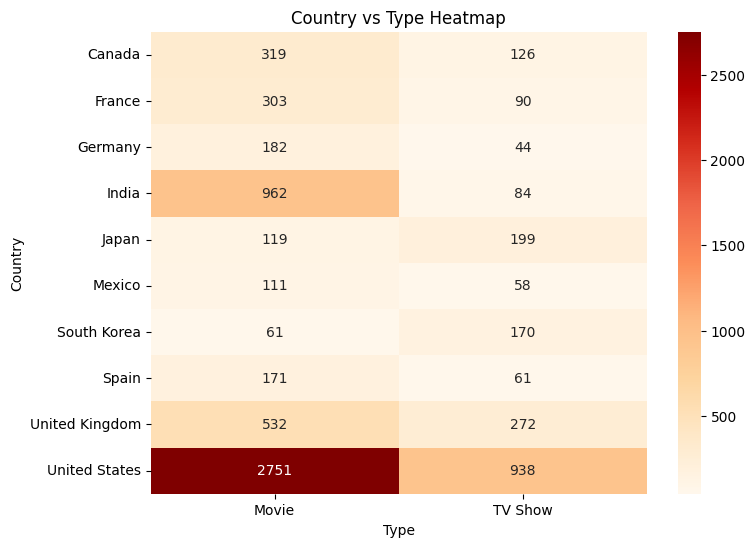

In [22]:
# country vs type
# Copy dataset
country_data = df1.copy()

# Split multiple countries and explode
country_data = country_data.assign(
    country=country_data['country'].str.split(', ')
).explode('country')

# Reset index to fix duplicate label error
country_data = country_data.reset_index(drop=True)

# Top 10 countries
top_countries = country_data['country'].value_counts().head(10).index

# Filter top countries
filtered_data = country_data[
    country_data['country'].isin(top_countries)
]

# Create crosstab
country_type = pd.crosstab(
    filtered_data['country'],
    filtered_data['type']
)

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    country_type,
    annot=True,
    cmap='OrRd',
    fmt='d'
)

plt.title("Country vs Type Heatmap")
plt.xlabel("Type")
plt.ylabel("Country")

plt.show()

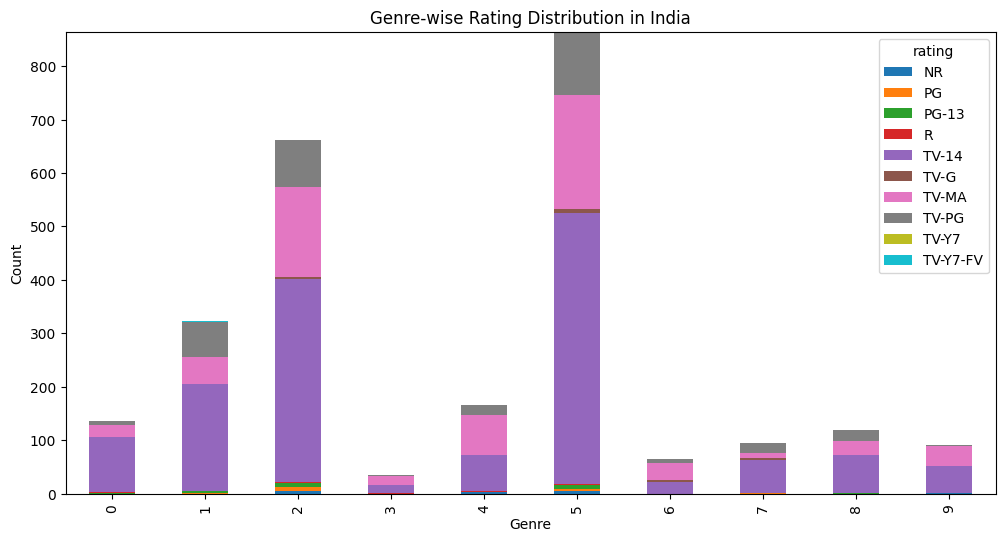

In [37]:
# india rating distribution ,genre wise
genre_rating.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Genre-wise Rating Distribution in India")

plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()